# 01 · Unusual behaviour / anomaly detection (models.md §1)

**v2.** One `IsolationForest` + `StandardScaler` per machine type **and state** (idle / working)
on rolling-window telemetry features, plus a sensor-glitch vs real-fault decision layer. Trained on the full 90-day synthetic run
(`data/output/telemetry.parquet`).

* Split by time: days 1–70 train, 71–80 validation, 81–90 test.
* Training rows exclude every failure drift window (from `maintenance_log` failures).
* `anomaly_label` / `anomaly_type` are **never** features. They and `data/output/truth/` are
  used only to evaluate (and, on validation days only, to compare rule variants).
* Evaluation covers **injected** anomaly types only. `pre_failure_*` belongs to predictive maintenance.

Feature code and decision logic live in `ml/inference/anomaly.py`, so notebook and backend
compute exactly the same thing.

In [1]:
import json, sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
while not (ROOT / "CLAUDE.md").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from ml.inference.anomaly import (FEATURE_COLUMNS, FEATURE_SIGNALS, INPUT_COLUMNS, STATES,
                                  build_features, classify, model_key)

DATA = ROOT / "data" / "output"
ART = ROOT / "ml" / "artifacts" / "anomaly"
ART.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
START = pd.Timestamp("2026-06-01", tz="UTC")
IF_PARAMS = dict(n_estimators=200, contamination=0.03, max_samples="auto", max_features=1.0,
                 random_state=RANDOM_STATE)
INJECTED = ["overheating", "hydraulic_leak", "excessive_idle", "battery_fault", "sensor_glitch",
            "unsafe_operation"]
TAIL = pd.Timedelta(minutes=5)  # rolling features trail the event end by up to 5 min
pd.set_option("display.width", 160)

# v1 results (committed metrics) for the before/after table
_prev = json.loads((ART / "metrics.json").read_text()) if (ART / "metrics.json").exists() else {}
V1_TEST = _prev["test"] if _prev.get("version") == "v1" else _prev.get("v1_test")

## 1 · Data

In [2]:
tel = (pd.read_parquet(DATA / "telemetry.parquet")
         .sort_values(["machine_id", "ts"], kind="stable").reset_index(drop=True))
machines = pd.read_csv(DATA / "machines.csv")
machine_map = machines.set_index("machine_id").machine_type.to_dict()
shifts = pd.read_csv(DATA / "shifts.csv", parse_dates=["start_time", "end_time"])
failures = pd.read_csv(DATA / "truth" / "failures.csv", parse_dates=["failure_ts"])
events = pd.read_csv(DATA / "truth" / "anomaly_events.csv", parse_dates=["start_ts", "end_ts"])

tel["machine_type"] = tel.machine_id.map(machine_map)
day = (tel.ts - START).dt.days + 1
tel["split"] = np.select([day <= 70, day <= 80], ["train", "val"], "test")
print(tel.shape, tel.groupby("split").size().to_dict())

(652228, 28) {'test': 74003, 'train': 506409, 'val': 71816}


### Failure drift windows
Drift windows are defined in **engine hours** (`drift_window_h`). Engine hours advance by the full
shift length (cut at a failure), not by telemetry rows, so rebuild them per shift and mark every
row within `W` engine hours before a failure. Check: the last 20 % of each window must coincide
with the `pre_failure_*` rows.

In [3]:
sh = shifts.sort_values(["machine_id", "start_time"]).copy()
shift_end = sh.shift_id.map(failures.set_index("shift_id").failure_ts).fillna(sh.end_time)
sh["dur_h"] = (pd.to_datetime(shift_end, utc=True) - sh.start_time).dt.total_seconds() / 3600
sh["eh0"] = sh.groupby("machine_id").dur_h.cumsum() - sh.dur_h

eh = tel[["shift_id", "ts"]].merge(sh[["shift_id", "eh0", "start_time"]], on="shift_id", how="left")
tel["engine_h"] = (eh.eh0 + (eh.ts - eh.start_time).dt.total_seconds() / 3600).to_numpy()
f = failures.merge(sh[["shift_id", "eh0", "start_time"]], on="shift_id")
f["eh_fail"] = f.eh0 + (f.failure_ts - f.start_time).dt.total_seconds() / 3600

in_drift = np.zeros(len(tel), bool)
last20 = np.zeros(len(tel), bool)
for r in f.itertuples():
    m = (tel.machine_id == r.machine_id).to_numpy() & (tel.engine_h <= r.eh_fail).to_numpy()
    in_drift |= m & (tel.engine_h >= r.eh_fail - r.drift_window_h).to_numpy()
    last20 |= m & (tel.engine_h >= r.eh_fail - 0.2 * r.drift_window_h).to_numpy()
tel["in_drift"] = in_drift

pre = tel.anomaly_type.fillna("").str.startswith("pre_failure").to_numpy()
print(f"drift rows {in_drift.sum():,}  | pre_failure rows {pre.sum():,}, "
      f"of which inside reconstructed last 20 %: {(pre & last20).sum():,}")
assert (pre & last20).sum() / pre.sum() > 0.999

drift rows 184,673  | pre_failure rows 37,143, of which inside reconstructed last 20 %: 37,142


## 2 · Features (models.md §1 + v2)
Per machine, per minute, trailing time-based windows: for each of the 9 signals of §1 **plus
`pitch_deg`, `roll_deg`, `ground_speed_kmh` (v2)** the 5-min mean, 5-min std and 15-min slope;
`idle_pct30`; `rpm_per_load`; `fuel_per_load`; `coolant_minus_hyd_oil_c` (40 features).
`state` (idle / working, from `is_idle`) picks the model; `state_age_min` counts minutes since
the last idle↔working switch or data gap.

Before the windows are computed, single-minute sensor glitches are replaced by the previous
reading (see §4), so one spike does not contaminate the next 5 minutes of features.

In [4]:
feats, glitch = build_features(tel[INPUT_COLUMNS])       # explicit input columns only
assert (feats.machine_id.values == tel.machine_id.values).all() and (feats.ts.values == tel.ts.values).all()
assert not {"anomaly_label", "anomaly_type"} & set(FEATURE_COLUMNS)
print(len(FEATURE_COLUMNS), "features from", len(FEATURE_SIGNALS), "signals")
feats[FEATURE_COLUMNS].describe().T.round(2).head(12)

40 features from 12 signals


,count,mean,std,min,25%,50%,75%,max
engine_rpm_mean5,652228.0,1634.33,264.01,775.10,1510.26,1680.40,1825.32,2033.36
engine_rpm_std5,652228.0,85.11,107.12,0.00,18.38,32.51,94.62,557.41
engine_rpm_slope15,652228.0,1.49,30.01,-113.34,-10.88,0.44,12.64,147.86
engine_load_pct_mean5,652228.0,52.15,19.89,0.72,40.55,53.63,67.15,89.96
engine_load_pct_std5,652228.0,6.67,7.04,0.00,2.02,3.40,8.13,39.79
engine_load_pct_slope15,652228.0,0.09,2.11,-7.66,-0.95,0.04,1.09,10.50
coolant_temp_c_mean5,652228.0,87.38,4.22,76.68,83.93,87.19,90.55,114.69
coolant_temp_c_std5,652228.0,0.41,0.31,0.00,0.21,0.34,0.54,9.81
coolant_temp_c_slope15,652228.0,0.01,0.24,-14.24,-0.13,0.01,0.15,2.26
oil_pressure_kpa_mean5,652228.0,316.19,61.48,36.62,281.14,318.92,363.96,433.94


## 3 · Train: one IsolationForest + StandardScaler per machine type × state
Idle and working minutes have very different normal ranges; in v1 one model per type pooled
them and most false alerts sat at state switches. Each model is fitted on training days only,
excluding drift windows. `anomaly_score` = `-score_samples()` min–max scaled to 0–1 using the
training range of that model; a minute is flagged when the raw score exceeds the threshold
implied by `contamination=0.03`.

In [5]:
train_mask = (tel.split == "train").to_numpy() & ~tel.in_drift.to_numpy()
X_all = feats[FEATURE_COLUMNS].to_numpy(float)
state = feats.state.to_numpy()
raw = np.zeros(len(tel)); Z = np.zeros_like(X_all); flagged = np.zeros(len(tel), bool)
models, scalers, score_scale, n_train = {}, {}, {}, {}
for mt in sorted(tel.machine_type.unique()):
    for st in STATES:
        key = model_key(mt, st)
        rows = (tel.machine_type == mt).to_numpy() & (state == st)
        fit_rows = rows & train_mask
        scaler = StandardScaler().fit(X_all[fit_rows])
        model = IsolationForest(**IF_PARAMS, n_jobs=-1).fit(scaler.transform(X_all[fit_rows]))
        Z[rows] = scaler.transform(X_all[rows])
        raw[rows] = -model.score_samples(Z[rows])
        tr = raw[fit_rows]
        score_scale[key] = {"min": float(tr.min()), "max": float(tr.max()), "threshold": float(-model.offset_)}
        flagged[rows] = raw[rows] > score_scale[key]["threshold"]
        models[key], scalers[key], n_train[key] = model, scaler, int(fit_rows.sum())
print(n_train)
pd.DataFrame(score_scale).T

{'articulated_truck_idle': 10106, 'articulated_truck_working': 50942, 'dozer_idle': 10151, 'dozer_working': 44961, 'excavator_idle': 20454, 'excavator_working': 95146, 'wheel_loader_idle': 18103, 'wheel_loader_working': 85439}


,min,max,threshold
articulated_truck_idle,0.385206,0.598257,0.510462
articulated_truck_working,0.367078,0.682670,0.538580
dozer_idle,0.387200,0.591138,0.505842
dozer_working,0.366624,0.653200,0.547645
excavator_idle,0.396576,0.598435,0.509603
excavator_working,0.363708,0.660939,0.553895
wheel_loader_idle,0.393401,0.604052,0.508489
wheel_loader_working,0.359615,0.667331,0.555571


## 4 · Sensor glitch vs real fault
* **Sensor glitch** (`kind='sensor_glitch'`, info): exactly one signal reads outside its sensor
  validity range (e.g. coolant 0 or 150 °C, battery 0 V, oil pressure 0 with the engine running)
  and that signal was plausible the minute before. Causal and instant — needs only t−1 and t.
* **Real fault** (`kind='machine_fault'`, v2): a model flag counts only once the machine has been
  ≥ 5 minutes in its current state (an idle/working switch or data gap resets the clock), and the
  alert fires after **3 consecutive** counting flags.
* Anything else is `normal`.

In [6]:
kind = classify(feats, flagged, glitch)
at = tel.anomaly_type.fillna("none").to_numpy()
pd.crosstab(at[tel.split == "test"], kind[tel.split == "test"])

col_0,machine_fault,normal,sensor_glitch
row_0,,,
battery_fault,0,614,0
excessive_idle,0,912,0
hydraulic_leak,0,298,0
none,10,69728,0
overheating,5,413,0
pre_failure_electrical,0,952,0
pre_failure_undercarriage,0,947,0
sensor_glitch,0,0,19
unsafe_operation,7,98,0


## 5 · Rules-only baseline (models.md §R)
The alert rule engine's thresholds, applied to the same telemetry. `SEATBELT` is a behaviour rule,
not a machine anomaly, and `OVERSPEED` has no type limits defined yet; both are left out.

v1 found two rules causing most false alerts. v2 tightens them (variants compared on
**validation days only**):
* `HYD_PRESSURE_DROP`: v1 compared each minute with the max of the previous 3 and fired on
  ordinary pressure spikes and while **travelling** (tracks, not the implement: ~3.4 km/h, ~50 bar).
  v2: the 2-min mean pressure is < 65 % of the 3-min mean ending 3 min earlier, load > 40 % for
  the last 6 min, machine stationary (3-min mean speed < 2 km/h), baseline > 100 bar.
* `EXCESS_IDLE`: v1 fired on any idle stretch > 10 min. v2 adds "at high idle": mean rpm of the
  stretch > 1200.

In [7]:
def run_len(cond, key):
    c = pd.Series(np.asarray(cond, bool))
    grp = (~c | key.ne(key.shift()).to_numpy()).cumsum()
    return c.astype(int).groupby(grp.to_numpy()).cumsum().to_numpy()

key = tel.shift_id
g = tel.groupby("shift_id")
roll = lambda col, fn: g[col].transform(fn)
hp_prev3max = roll("hydraulic_pressure_bar", lambda s: s.shift(1).rolling(3, min_periods=1).max())
hp_now2 = roll("hydraulic_pressure_bar", lambda s: s.rolling(2).mean())
hp_base3 = roll("hydraulic_pressure_bar", lambda s: s.shift(3).rolling(3).mean())
load_min6 = roll("engine_load_pct", lambda s: s.rolling(6).min())
speed3 = roll("ground_speed_kmh", lambda s: s.rolling(3, min_periods=1).mean())
idle = tel.is_idle.to_numpy(bool)
idle_len = run_len(idle, key)
idle_run = (~pd.Series(idle) | key.ne(key.shift()).to_numpy()).cumsum().to_numpy()
idle_rpm_mean = tel.engine_rpm.where(idle).groupby(idle_run).transform(lambda s: s.expanding().mean()).to_numpy()

common = {
    "COOLANT_HIGH": run_len(tel.coolant_temp_c > 100, key) >= 2,
    "COOLANT_CRITICAL": tel.coolant_temp_c > 105,
    "HYD_OIL_HIGH": tel.hydraulic_oil_temp_c > 90,
    "OIL_PRESSURE_LOW": (tel.oil_pressure_kpa < 100) & (tel.engine_rpm > 1200),
    "BATTERY_LOW": run_len(tel.battery_voltage < 24, key) >= 5,
    "TIP_RISK": (tel.pitch_deg.abs() > 15) | (tel.roll_deg.abs() > 15),
    "FAULT_CODE": tel.fault_code.notna(),
}
rules_v1 = pd.DataFrame({**common,
    "HYD_PRESSURE_DROP": (tel.hydraulic_pressure_bar < 0.65 * hp_prev3max) & (tel.engine_load_pct > 40) & (hp_prev3max > 100),
    "EXCESS_IDLE": idle_len > 10,
}).astype(bool)
rules = pd.DataFrame({**common,
    "HYD_PRESSURE_DROP": (hp_now2 < 0.65 * hp_base3) & (load_min6 > 40) & (hp_base3 > 100) & (speed3 < 2),
    "EXCESS_IDLE": (idle_len > 10) & (idle_rpm_mean > 1200),
}).astype(bool)
rule_alert = rules.any(axis=1).to_numpy()
normal_test = (tel.split == "test").to_numpy() & (at == "none")
pd.DataFrame({"v1": rules_v1[normal_test].mean(), "v2": rules[normal_test].mean()}).round(4).rename_axis("share of normal test minutes firing")

,v1,v2
share of normal test minutes firing,,
COOLANT_HIGH,0.0000,0.0000
COOLANT_CRITICAL,0.0000,0.0000
HYD_OIL_HIGH,0.0000,0.0000
OIL_PRESSURE_LOW,0.0000,0.0000
BATTERY_LOW,0.0000,0.0000
TIP_RISK,0.0000,0.0000
FAULT_CODE,0.0000,0.0000
HYD_PRESSURE_DROP,0.0238,0.0033
EXCESS_IDLE,0.0077,0.0032


## 6 · Evaluation
Three detectors: **rules only** (v2 rules), **model only** and **rules + model** (what ships: a rule or a
confirmed model fault alerts; a minute the model marks `sensor_glitch` is downgraded to info,
which suppresses the rules' false critical alert).

Metrics, per injected `anomaly_type`, on the chosen split:
* **Event recall** — share of events with a correct alert between start and end + 5 min
  (`sensor_glitch` must be classified as a glitch; every other type as a fault).
* **Median detection delay** — minutes from event start to the first correct alert.
* **Minute precision / recall / F1** — one type vs normal minutes: the population is the normal
  minutes plus that type's minutes (other types, `pre_failure_*` rows and the 5-min tails are left out).
* Overall: false alert episodes (runs of alerting minutes that touch no injected event) per
  100 machine-hours of normal operation.

In [8]:
ev_all = events[events.anomaly_type.isin(INJECTED)].copy()
tel_idx = {m: (g.index.to_numpy(), g.ts.dt.tz_convert(None).to_numpy()) for m, g in tel.groupby("machine_id")}

# rows inside an injected event (+ tail), per type
event_rows = np.zeros(len(tel), bool); tail_rows = np.zeros(len(tel), bool)
for e in ev_all.itertuples():
    idx, ts = tel_idx[e.machine_id]
    s, en, t = [np.datetime64(x.tz_convert(None)) for x in (e.start_ts, e.end_ts, e.end_ts + TAIL)]
    event_rows[idx[(ts >= s) & (ts < en)]] = True
    tail_rows[idx[(ts >= en) & (ts < t)]] = True

def detectors(kind):
    fault = kind == "machine_fault"; gl = kind == "sensor_glitch"
    return {
        "rules": {"fault": rule_alert, "glitch": np.zeros(len(tel), bool)},
        "model": {"fault": fault, "glitch": gl},
        "rules+model": {"fault": (rule_alert & ~gl) | fault, "glitch": gl},
    }

def evaluate(kind, split):
    in_split = (tel.split == split).to_numpy()
    ev = ev_all[ev_all.start_ts.map(lambda t: (t - START).days + 1).between(*{"val": (71, 80), "test": (81, 90)}[split])]
    normal = in_split & (at == "none") & ~tail_rows
    out, overall = {}, {}
    for name, d in detectors(kind).items():
        per = {}
        rec_all, delay_all = [], []
        for typ in INJECTED:
            alert = d["glitch"] if typ == "sensor_glitch" else d["fault"]
            hits, delays = [], []
            for e in ev[ev.anomaly_type == typ].itertuples():
                idx, ts = tel_idx[e.machine_id]
                w = idx[(ts >= np.datetime64(e.start_ts.tz_convert(None))) & (ts < np.datetime64((e.end_ts + TAIL).tz_convert(None)))]
                h = w[alert[w]]
                hits.append(len(h) > 0)
                if len(h):
                    delays.append((tel.ts.iat[h[0]] - e.start_ts).total_seconds() / 60)
            pos = in_split & (at == typ)
            tp, fn, fp = (alert & pos).sum(), (~alert & pos).sum(), (alert & normal).sum()
            p = tp / (tp + fp) if tp + fp else 0.0; r = tp / (tp + fn) if tp + fn else 0.0
            per[typ] = {"events": len(hits), "event_recall": round(float(np.mean(hits)), 3),
                        "median_delay_min": round(float(np.median(delays)), 1) if delays else None,
                        "minute_precision": round(float(p), 3), "minute_recall": round(float(r), 3),
                        "minute_f1": round(float(2 * p * r / (p + r)) if p + r else 0.0, 3)}
            rec_all += hits; delay_all += delays
        any_alert = d["fault"] | d["glitch"]
        # false alert episodes: runs of alert minutes (same shift) that touch no event row / tail
        a = pd.Series(any_alert & in_split)
        start = a & ~(a.shift(fill_value=False) & tel.shift_id.eq(tel.shift_id.shift()))
        run = start.cumsum().where(a)
        touches = pd.Series(event_rows | tail_rows | (at != "none")).groupby(run).any()
        n_false = int((~touches).sum())
        hours = normal.sum() / 60
        overall = {"event_recall": round(float(np.mean(rec_all)), 3),
                   "median_delay_min": round(float(np.median(delay_all)), 1),
                   "false_alerts_per_100_machine_h": round(100 * n_false / hours, 2),
                   "normal_minutes_alerting_pct": round(100 * float(any_alert[normal].mean()), 2)}
        out[name] = {"per_type": per, "overall": overall}
    return out

def table(res, cols=("event_recall", "median_delay_min", "minute_precision", "minute_recall", "minute_f1")):
    return pd.concat({k: pd.DataFrame(v["per_type"]).T[list(cols)] for k, v in res.items()}, axis=1)

val_spec = evaluate(kind, "val")
print(pd.DataFrame({k: v["overall"] for k, v in val_spec.items()}))
table(val_spec)

                                rules  model  rules+model
event_recall                     0.65  0.312        0.912
median_delay_min                 2.00  0.000        2.000
false_alerts_per_100_machine_h  18.01  0.630       18.640
normal_minutes_alerting_pct      0.61  0.020        0.630


rules                                                                  model                                                  \
                 event_recall median_delay_min minute_precision minute_recall minute_f1 event_recall median_delay_min minute_precision minute_recall   
overheating             1.000             11.0            0.119         0.355     0.178        0.000              NaN            0.000         0.000   
hydraulic_leak          0.846              2.0            0.268         0.575     0.366        0.000              NaN            0.000         0.000   
excessive_idle          1.000             10.0            0.528         0.794     0.634        0.000              NaN            0.000         0.000   
battery_fault           1.000              2.0            0.561         0.919     0.697        0.000              NaN            0.000         0.000   
sensor_glitch           0.000              NaN            0.000         0.000     0.000        1.000              0.0            1.000         1.000   
unsafe_operation        0.706              1.0            0.173         0.472     0.253        0.235              7.0            0.238         0.028   

                            rules+model                                                            
                 minute_f1 event_recall median_delay_min minute_precision minute_recall minute_f1  
overheating           0.00        1.000             11.0            0.115         0.355     0.174  
hydraulic_leak        0.00        0.846              2.0            0.260         0.575     0.359  
excessive_idle        0.00        1.000             10.0            0.518         0.794     0.627  
battery_fault         0.00        1.000              2.0            0.551         0.919     0.689  
sensor_glitch         1.00        1.000              0.0            1.000         1.000     1.000  
unsafe_operation      0.05        0.706              1.0            0.169         0.478     0.250

## 7 · The v2 round
v1 kept the spec threshold after one threshold sweep (recall could not be bought without
tripling false alerts). v2 is the single approved round of structural changes — separate
idle/working models, pitch/roll/speed features, 5-min settle after a state switch, 3-minute
persistence, two tightened rules — with the spec threshold (contamination 0.03) unchanged.
Validation numbers are above; the test period is evaluated once, below.

## 8 · Test results (days 81–90)

In [9]:
test_res = evaluate(kind, "test")
print(pd.DataFrame({k: v["overall"] for k, v in test_res.items()}))
table(test_res)

                                 rules  model  rules+model
event_recall                     0.736  0.276        0.966
median_delay_min                 6.500  0.000        2.000
false_alerts_per_100_machine_h  16.880  0.610       17.490
normal_minutes_alerting_pct      0.630  0.010        0.640


rules                                                                  model                                                  \
                 event_recall median_delay_min minute_precision minute_recall minute_f1 event_recall median_delay_min minute_precision minute_recall   
overheating             1.000             11.5            0.248         0.344     0.288        0.214             28.0            0.333         0.012   
hydraulic_leak          0.929              2.0            0.297         0.621     0.402        0.000              NaN            0.000         0.000   
excessive_idle          1.000             10.0            0.624         0.795     0.699        0.000              NaN            0.000         0.000   
battery_fault           1.000              4.0            0.564         0.922     0.700        0.000              NaN            0.000         0.000   
sensor_glitch           0.000              NaN            0.000         0.000     0.000        1.000              0.0            1.000         1.000   
unsafe_operation        0.727              1.0            0.121         0.571     0.199        0.182              6.5            0.412         0.067   

                            rules+model                                                            
                 minute_f1 event_recall median_delay_min minute_precision minute_recall minute_f1  
overheating          0.023        1.000             11.5            0.250         0.356     0.294  
hydraulic_leak       0.000        0.929              2.0            0.293         0.621     0.398  
excessive_idle       0.000        1.000             10.0            0.619         0.795     0.696  
battery_fault        0.000        1.000              4.0            0.559         0.922     0.696  
sensor_glitch        1.000        1.000              0.0            1.000         1.000     1.000  
unsafe_operation     0.115        0.818              1.0            0.124         0.600     0.205

In [10]:
TARGET_RECALL, TARGET_DELAY = 0.8, 5.0              # models.md §1, model alone
GOAL_RECALL, GOAL_FALSE = 0.9, 40.0                  # v2 goal, rules + model
m, c = test_res["model"]["overall"], test_res["rules+model"]["overall"]
targets = {"model_recall_ge_0.8": m["event_recall"] >= TARGET_RECALL,
           "model_median_delay_le_5_min": m["median_delay_min"] <= TARGET_DELAY,
           "combined_recall_ge_0.9": c["event_recall"] >= GOAL_RECALL,
           "combined_false_alerts_le_40_per_100h": c["false_alerts_per_100_machine_h"] <= GOAL_FALSE}
print(targets)
versions = {"v2": test_res, **({"v1": V1_TEST} if V1_TEST else {})}
compare = pd.DataFrame({f"{v} {d}": res[d]["overall"] for v, res in sorted(versions.items())
                        for d in ("rules", "model", "rules+model")}).T
compare

{'model_recall_ge_0.8': False, 'model_median_delay_le_5_min': True, 'combined_recall_ge_0.9': True, 'combined_false_alerts_le_40_per_100h': np.True_}


,event_recall,median_delay_min,false_alerts_per_100_machine_h,normal_minutes_alerting_pct
v1 rules,0.770,6.0,90.73,3.12
v1 model,0.621,3.0,50.04,1.61
v1 rules+model,1.000,2.0,138.26,4.71
v2 rules,0.736,6.5,16.88,0.63
v2 model,0.276,0.0,0.61,0.01
v2 rules+model,0.966,2.0,17.49,0.64


## 9 · Result chart

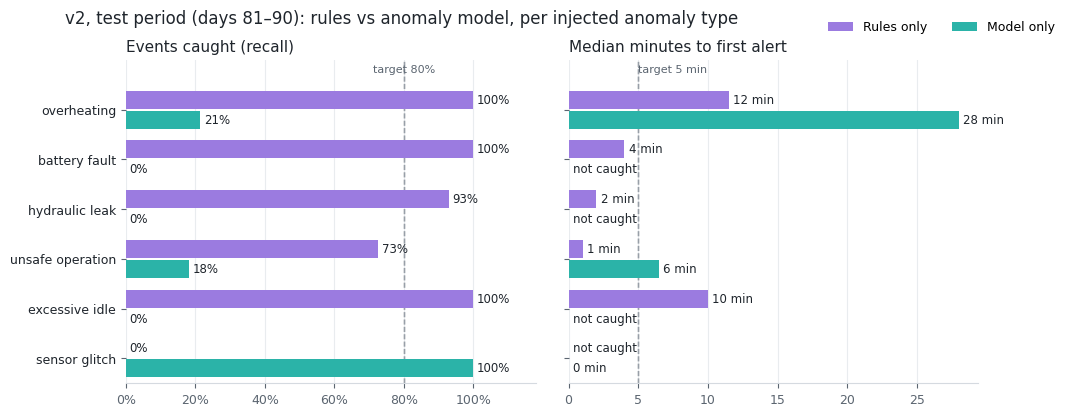

In [11]:
# design.md categorical tokens: teal and violet (validated: CVD dE 12.0, normal-vision dE 21.8)
TEAL, VIOLET, INK, MUTED, GRID = "#2BB3A8", "#9B7BE0", "#1F252C", "#5B6570", "#D5DAE0"
order = ["overheating", "battery_fault", "hydraulic_leak", "unsafe_operation", "excessive_idle", "sensor_glitch"]
series = [("Rules only", "rules", VIOLET), ("Model only", "model", TEAL)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, gridspec_kw={"wspace": 0.08})
y = np.arange(len(order)); h = 0.36
for ax, metric, title, fmt in [(axes[0], "event_recall", "Events caught (recall)", "{:.0%}"),
                               (axes[1], "median_delay_min", "Median minutes to first alert", "{:.0f} min")]:
    for i, (label, keyname, color) in enumerate(series):
        vals = [test_res[keyname]["per_type"][t][metric] for t in order]
        pos = y + (i - 0.5) * (h + 0.04)
        ax.barh(pos, [v or 0 for v in vals], height=h, color=color, label=label)
        for p_, v in zip(pos, vals):
            ax.text((v or 0) + (0.01 if metric == "event_recall" else 0.3), p_,
                    "not caught" if v is None else fmt.format(v), va="center", fontsize=8.5, color=INK)
    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.grid(axis="x", color=GRID, alpha=0.5); ax.set_axisbelow(True)
    for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9); ax.spines["bottom"].set_color(GRID)
axes[0].axvline(0.8, color=MUTED, lw=1, ls="--", zorder=0); axes[0].text(0.8, -0.75, "target 80%", fontsize=8, color=MUTED, ha="center")
axes[1].axvline(5, color=MUTED, lw=1, ls="--", zorder=0); axes[1].text(5, -0.75, "target 5 min", fontsize=8, color=MUTED, ha="left")
axes[0].set_xlim(0, 1.18); axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[0].set_yticks(y, [t.replace("_", " ") for t in order], color=INK)
axes[0].set_ylim(len(order) - 0.5, -1.0)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.98, 1.0))
fig.suptitle("v2, test period (days 81–90): rules vs anomaly model, per injected anomaly type", fontsize=12, color=INK, x=0.07, ha="left", y=1.0)
fig.savefig(ART / "recall_delay.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 10 · Save artifacts

In [12]:
for old in ART.glob("*.joblib"):
    old.unlink()                                      # v1 used one file per machine type
for k in models:
    joblib.dump(models[k], ART / f"iforest_{k}.joblib", compress=3)
    joblib.dump(scalers[k], ART / f"scaler_{k}.joblib", compress=3)
(ART / "feature_list.json").write_text(json.dumps(FEATURE_COLUMNS, indent=2))
config = {"version": "v2", "machine_types": sorted(tel.machine_type.unique()), "states": list(STATES),
          "model_keys": sorted(models), "machine_map": machine_map, "score_scale": score_scale,
          "isolation_forest": IF_PARAMS, "settle_min": 5, "persist_min": 3}
(ART / "config.json").write_text(json.dumps(config, indent=2))
metrics = {
    "model_name": "anomaly", "version": "v2", "sklearn_version": sklearn.__version__,
    "split": {"train_days": [1, 70], "val_days": [71, 80], "test_days": [81, 90]},
    "train_rows": n_train, "train_excludes": "failure drift windows (engine hours, full W)",
    "evaluated_types": INJECTED, "event_tail_min": 5,
    "targets": {"model_recall": TARGET_RECALL, "model_median_delay_min": TARGET_DELAY,
                "combined_recall": GOAL_RECALL, "combined_false_alerts_per_100_machine_h": GOAL_FALSE,
                "met": targets},
    "test": test_res, "validation": val_spec, "v1_test": V1_TEST,
    "v2_changes": ["model per machine_type x state (idle/working)", "pitch/roll/speed features",
                   "model flags ignored 5 min after an idle/working switch or gap",
                   "model fault after 3 consecutive flags (multi-signal shortcut removed)",
                   "HYD_PRESSURE_DROP: 2-min vs prior 3-min mean, load>40 for 6 min, stationary",
                   "EXCESS_IDLE: >10 min idle at mean rpm > 1200"],
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2, default=lambda o: bool(o) if isinstance(o, np.bool_) else float(o)))
sizes = {p.name: p.stat().st_size for p in ART.iterdir()}
print(f"total {sum(sizes.values()) / 1e6:.1f} MB")
sizes

total 5.1 MB


{'config.json': 2136,
 'feature_list.json': 1088,
 'iforest_articulated_truck_idle.joblib': 641590,
 'iforest_articulated_truck_working.joblib': 613970,
 'iforest_dozer_idle.joblib': 645097,
 'iforest_dozer_working.joblib': 609425,
 'iforest_excavator_idle.joblib': 654000,
 'iforest_excavator_working.joblib': 602651,
 'iforest_wheel_loader_idle.joblib': 667831,
 'iforest_wheel_loader_working.joblib': 593058,
 'metrics.json': 16528,
 'README.md': 3968,
 'recall_delay.png': 84469,
 'scaler_articulated_truck_idle.joblib': 1364,
 'scaler_articulated_truck_working.joblib': 1363,
 'scaler_dozer_idle.joblib': 1419,
 'scaler_dozer_working.joblib': 1413,
 'scaler_excavator_idle.joblib': 1415,
 'scaler_excavator_working.joblib': 1411,
 'scaler_wheel_loader_idle.joblib': 1413,
 'scaler_wheel_loader_working.joblib': 1411}

## 11 · Parity check: live scoring = batch scoring
`score_anomaly` on a trailing 60-minute window must give the same score and kind as the batch
pipeline for the same minute.

In [13]:
import importlib, ml.inference.anomaly as A
importlib.reload(A)
rng = np.random.default_rng(RANDOM_STATE)
test_rows = np.flatnonzero((tel.split == "test").to_numpy())
sample = np.concatenate([rng.choice(test_rows, 25, replace=False),
                         rng.choice(test_rows[kind[test_rows] != "normal"], 15, replace=False)])
bad = 0
for i in sample:
    row = tel.iloc[i]
    win = tel[(tel.machine_id == row.machine_id) & (tel.ts > row.ts - pd.Timedelta(minutes=60)) & (tel.ts <= row.ts)]
    live = A.score_anomaly(win[INPUT_COLUMNS])
    c = score_scale[model_key(row.machine_type, state[i])]
    batch = float(np.clip((raw[i] - c["min"]) / (c["max"] - c["min"]), 0, 1))
    bad += abs(live["anomaly_score"] - round(batch, 3)) > 1e-3 or live["kind"] != kind[i]
print("mismatches:", bad, "of", len(sample)); assert bad == 0
live

mismatches: 0 of 40


{'machine_id': 'M02',
 'ts': '2026-08-22T02:09:00Z',
 'anomaly_score': 0.216,
 'is_anomaly': True,
 'kind': 'sensor_glitch',
 'top_signals': [{'feature': 'coolant_temp_c', 'z': -20.46},
  {'feature': 'vibration_rms_g_mean5', 'z': 1.97},
  {'feature': 'vibration_rms_g_std5', 'z': 1.59}]}